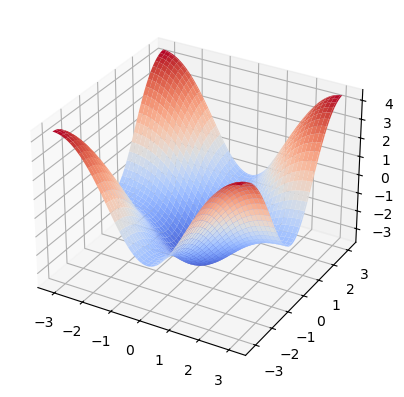

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

t = 1.0
#t1 = 0
#t2 = 0
t1 = -0.2
t2 = 0.1

#Q = 0
Q = [np.pi, np.pi]

Nk = 128
kx_list = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
ky_list = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
KX, KY = np.meshgrid(kx_list, ky_list)
N = Nk * Nk

def band(kx, ky):
    return -2.0*t*(np.cos(kx) + np.cos(ky)) - 4.0*t1*np.cos(kx)*np.cos(ky) - 2*t2*(np.cos(2*kx) + np.cos(2*ky))

def band_Q(kx, ky):
    return -2.0*t*(np.cos(kx+Q[0]) + np.cos(ky+Q[1])) - 4.0*t1*np.cos(kx+Q[0])*np.cos(ky+Q[1]) - 2*t2*(np.cos(2*(kx+Q[0])) + np.cos(2*(ky+Q[1])))

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
surf = ax.plot_surface(KX, KY, band(KX, KY), cmap=cm.coolwarm)
#surf = ax.plot_surface(KX, KY, band_Q(KX, KY), cmap=cm.coolwarm)

#gamma = np.cos(KX) - np.cos(KY)
#plt.contourf(KX, KY, gamma)

5.21539568901062


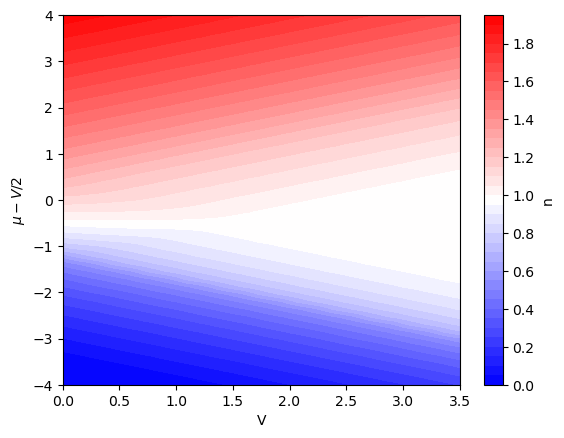

In [3]:
#Fermi arc model density polt Fig1 PHYSICAL REVIEW LETTERS 133, 166501 (2024)
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve
from scipy.optimize import brentq
import matplotlib.cm as cm
import time

Nk = 128
kx_list = np.linspace(0, np.pi, Nk, endpoint=False)
ky_list = np.linspace(0, np.pi, Nk, endpoint=False)
KX, KY = np.meshgrid(kx_list, ky_list)
N = Nk * Nk

def band(kx, ky):
    return -2.0*t*(np.cos(kx) + np.cos(ky)) - 4.0*t1*np.cos(kx)*np.cos(ky) - 2*t2*(np.cos(2*kx) + np.cos(2*ky))

def band_Q(kx, ky):
    return -2.0*t*(np.cos(kx+Q[0]) + np.cos(ky+Q[1])) - 4.0*t1*np.cos(kx+Q[0])*np.cos(ky+Q[1]) - 2*t2*(np.cos(2*(kx+Q[0])) + np.cos(2*(ky+Q[1])))

def occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T):
    epsilon_minus_mu = epsilon - mu
    epsilon_Q_minus_mu = epsilon_Q - mu
    if T < 1e-8:
        T = 1e-8
    beta = 1.0/T
    E_1 = -beta*epsilon_Q_minus_mu
    E_2 = -beta*(epsilon_minus_mu + epsilon_Q_minus_mu + U)
    E_3 = -beta*epsilon_minus_mu
    E_0 = np.full_like(E_1, 0)
    E_max = np.maximum.reduce([E_0, E_1, E_2, E_3])
    numerator = np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    denominator = np.exp(E_0 - E_max) + np.exp(E_3 - E_max) + np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    return numerator/denominator

def average_occupation(mu, T, U, KX, KY, N):
    epsilon = band(KX, KY)
    epsilon_Q = band_Q(KX, KY)
    n_k = occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T)
    return 2.0*np.sum(n_k) / N

T = 1e-6
N_densplot = 50
U = np.linspace(0, 3.5, N_densplot)
mu_minus_U_half = np.linspace(-4, 4, N_densplot)
U_2d, mu_minus_U_half_2d = np.meshgrid(U, mu_minus_U_half)

average_occupation_2d = np.full_like(U_2d, 0)

start_time = time.time()
for i in range(0, N_densplot):
    for j in range(0, N_densplot):
        average_occupation_2d[i, j] = average_occupation(mu_minus_U_half_2d[i, j] + U_2d[i, j]/2, T, U_2d[i, j], KX, KY, N)

fig, ax = plt.subplots()
N_levels = 40
C = plt.contourf(U_2d, mu_minus_U_half_2d, average_occupation_2d, cmap=cm.bwr, levels=N_levels)
cbar = fig.colorbar(C, ax=ax, label='n')
end_time = time.time()
print(end_time-start_time)
plt.xlabel('V')
plt.ylabel('$\\mu-V/2$')
#plt.savefig('Fermi_arc_n.png')
plt.show()

C:\Users\fishb\AppData\Local\Temp\ipykernel_53644\459011221.py:81: RuntimeWarning: overflow encountered in cosh
  (beta/2.0)*n_k*(1-n_k)*1.0/np.cosh(beta*U/4.0)**2,
C:\Users\fishb\AppData\Local\Temp\ipykernel_53644\459011221.py:81: RuntimeWarning: overflow encountered in scalar power
  (beta/2.0)*n_k*(1-n_k)*1.0/np.cosh(beta*U/4.0)**2,


mu = -3.5 low Tc
mu = -3.2586206896551726 low Tc
mu = -3.0172413793103448 low Tc
mu = -2.7758620689655173 low Tc
mu = -2.5344827586206895 low Tc
mu = -2.293103448275862 low Tc
mu = -2.0517241379310347 low Tc
mu = 1.56896551724138 low Tc
mu = 2.293103448275862 low Tc
mu = 2.5344827586206895 low Tc
mu = 2.775862068965518 low Tc
mu = 3.017241379310345 low Tc
mu = 3.2586206896551726 low Tc
mu = 3.5 low Tc
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0005152379617950128, 0.01708118661063054, 0.07534498783052501, 0.0658476648172107, 0.018099643045915555, 0.0021268599850563343, 0.012816778046595938, 0.018322303832665403, 0.012497347515846443, 0.00757064460220209, 0.005546886693258767, 0.0034769853392764565, 0.001289905418051527, 0.0006466594089886403, 0.0, 0.0003977606471519166, 0.00012477317446936328, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


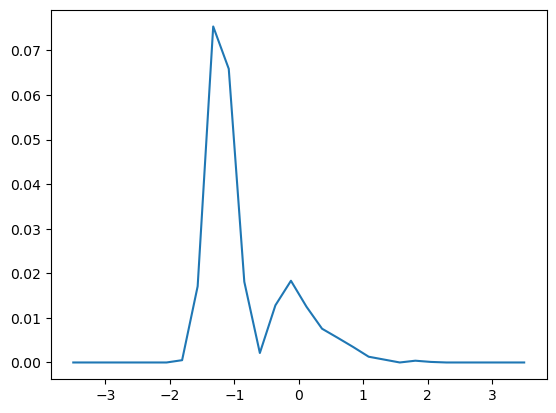

In [ ]:
#Fermi arc model Tc vs mu equation 24
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve
from scipy.optimize import brentq
import time

kB = 1.0
t = 1.0

t1 = -0.2
t2 = 0.1
#t1 = 0
#t2 = 0

d = 2.0    #spatial dimension
W = 4*d*t  #band width
g = 0.1*W  #pair coupling

Q = [np.pi, np.pi]
#Q = [0, 0]

U = 0.1*W
#V = 2*U

Nk = 128
kx_list = np.linspace(0, np.pi, Nk, endpoint=False)
ky_list = np.linspace(0, np.pi, Nk, endpoint=False)
KX, KY = np.meshgrid(kx_list, ky_list)
N = Nk * Nk

def band(kx, ky):
    return -2.0*t*(np.cos(kx) + np.cos(ky)) - 4.0*t1*np.cos(kx)*np.cos(ky) - 2*t2*(np.cos(2*kx) + np.cos(2*ky))

def band_Q(kx, ky):
    return -2.0*t*(np.cos(kx+Q[0]) + np.cos(ky+Q[1])) - 4.0*t1*np.cos(kx+Q[0])*np.cos(ky+Q[1]) - 2*t2*(np.cos(2*(kx+Q[0])) + np.cos(2*(ky+Q[1])))

def occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T):
    epsilon_minus_mu = epsilon - mu
    epsilon_Q_minus_mu = epsilon_Q - mu
    if T < 1e-8:
        T = 1e-8
    beta = 1.0/T
    E_1 = -beta*epsilon_Q_minus_mu
    E_2 = -beta*(epsilon_minus_mu + epsilon_Q_minus_mu + U)
    E_3 = -beta*epsilon_minus_mu
    E_0 = np.full_like(E_1, 0)
    E_max = np.maximum.reduce([E_0, E_1, E_2, E_3])
    numerator = np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    denominator = np.exp(E_0 - E_max) + np.exp(E_3 - E_max) + np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    return numerator/denominator

def chi0_hk(T, mu, U):
    if T < 1e-8:
        T = 1e-8
    beta = 1.0/T
    epsilon = band(KX, KY)
    epsilon_Q = band_Q(KX, KY)
    n_k = occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T)
    epsilon_minus_mu = epsilon - mu
    epsilon_Q_minus_mu = epsilon_Q - mu
    gamma = np.cos(KX) - np.cos(KY)
    #gamma = 1
    
    term_1_denominator = 2.0*epsilon_minus_mu
    term_1_numerator = gamma**2*(1.0 - n_k)**2*np.tanh(beta*epsilon_minus_mu/2.0)
    term_1 = np.where(np.abs(epsilon_minus_mu) < 1e-6, 
                      (1.0 - n_k)**2*beta/4.0,
                     term_1_numerator/term_1_denominator)
    
    epsilon_plus_U = epsilon_minus_mu + U
    term_2_denominator = 2.0*epsilon_plus_U
    term_2_numerator = gamma**2*n_k**2*np.tanh(beta*epsilon_plus_U/2.0)
    term_2 = np.where(np.abs(epsilon_plus_U) < 1e-6, 
                      n_k**2*beta/4.0,
                     term_2_numerator/term_2_denominator)

    term_3_denominator = 2.0*epsilon_minus_mu + U
    term_3_numerator = gamma**2*n_k*(1-n_k)*(np.tanh(beta*epsilon_minus_mu/2.0) + np.tanh(beta*epsilon_plus_U/2.0))
    term_3 = np.where(np.abs(2.0*epsilon_minus_mu + U) < 1e-6, 
                      (beta/2.0)*n_k*(1-n_k)*1.0/np.cosh(beta*U/4.0)**2,
                     term_3_numerator/term_3_denominator)
    #term_3 = 0
    
    chi0 = np.sum(term_1 + term_2 + term_3)/N
    return chi0

def tc_equation(T, mu, U, g):
    return g*chi0_hk(T, mu, U) - 1.0

def find_Tc(mu, U, g):
    T_max = 1.0
    T_min = 1e-7
    if tc_equation(T_max, mu, U, g) > 0:
        T_high = T_max
        while tc_equation(T_high, mu, U, g) > 0 and T_high < 10.0:
            T_high *= 2
        T_max = T_high
        print('T_high=', T_max)
        
    if tc_equation(T_min, mu, U, g) < 0:
        print('mu =', mu, 'low Tc')
        return 0.0
         
    try:
        Tc = brentq(tc_equation, T_min, T_max, args=(mu, U, g))
        return Tc
    except ValueError:
        return 0.0
    return Tc

mu_list = np.linspace(-3.5, 3.5, 30)
Tc_result = [find_Tc(mu, U, g) for mu in mu_list]

plt.plot(mu_list, Tc_result)
print(Tc_result)

mu = -3.5 low Tc
mu = -3.2586206896551726 low Tc
mu = -3.0172413793103448 low Tc
mu = -2.7758620689655173 low Tc
mu = -2.5344827586206895 low Tc
mu = -2.293103448275862 low Tc
mu = -2.0517241379310347 low Tc
mu = 1.56896551724138 low Tc
mu = 2.293103448275862 low Tc
mu = 2.5344827586206895 low Tc
mu = 2.775862068965518 low Tc
mu = 3.017241379310345 low Tc
mu = 3.2586206896551726 low Tc
mu = 3.5 low Tc
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0005152379617950128, 0.01708118661063054, 0.07534498783052501, 0.06584766481721072, 0.018099643045915555, 0.0021268599850563343, 0.012816778046595943, 0.018322303832665403, 0.012497347515846443, 0.00757064460220209, 0.005546886693258767, 0.0034769853392764565, 0.001289905418051527, 0.0006466594089886403, 0.0, 0.0003977606471519166, 0.00012477317446936333, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


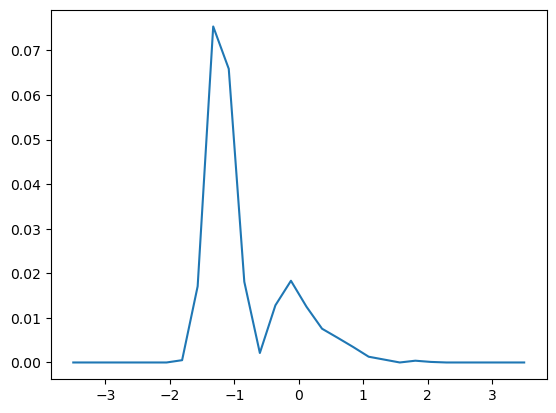

In [4]:
#Fermi arc model Tc equation 25 (non-interacting interacting splited)
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve
from scipy.optimize import brentq
import time

kB = 1.0
t = 1.0

t1 = -0.2
t2 = 0.1
#t1 = 0
#t2 = 0

d = 2.0    #spatial dimension
W = 4*d*t  #band width
g = 0.1*W  #pair coupling

Q = [np.pi, np.pi]
#Q = [0, 0]

U = 0.1*W
#V = 2*U

Nk = 128
kx_list = np.linspace(0, np.pi, Nk, endpoint=False)
ky_list = np.linspace(0, np.pi, Nk, endpoint=False)
KX, KY = np.meshgrid(kx_list, ky_list)
N = Nk * Nk

def band(kx, ky):
    return -2.0*t*(np.cos(kx) + np.cos(ky)) - 4.0*t1*np.cos(kx)*np.cos(ky) - 2*t2*(np.cos(2*kx) + np.cos(2*ky))

def band_Q(kx, ky):
    return -2.0*t*(np.cos(kx+Q[0]) + np.cos(ky+Q[1])) - 4.0*t1*np.cos(kx+Q[0])*np.cos(ky+Q[1]) - 2*t2*(np.cos(2*(kx+Q[0])) + np.cos(2*(ky+Q[1])))

def occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T):
    epsilon_minus_mu = epsilon - mu
    epsilon_Q_minus_mu = epsilon_Q - mu
    if T < 1e-8:
        T = 1e-8
    beta = 1.0/T
    E_1 = -beta*epsilon_Q_minus_mu
    E_2 = -beta*(epsilon_minus_mu + epsilon_Q_minus_mu + U)
    E_3 = -beta*epsilon_minus_mu
    E_0 = np.full_like(E_1, 0)
    E_max = np.maximum.reduce([E_0, E_1, E_2, E_3])
    numerator = np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    denominator = np.exp(E_0 - E_max) + np.exp(E_3 - E_max) + np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    return numerator/denominator

def chi0_hk(T, mu, U):
    if T < 1e-8:
        T = 1e-8
    beta = 1.0/T
    epsilon = band(KX, KY)
    epsilon_Q = band_Q(KX, KY)
    n_k = occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T)
    epsilon_minus_mu = epsilon - mu
    epsilon_Q_minus_mu = epsilon_Q - mu
    gamma = np.cos(KX) - np.cos(KY)
    #gamma = 1
    
    term_1_denominator = 2.0*epsilon_minus_mu
    term_1_numerator = gamma*gamma*(1.0 - n_k)*np.tanh(beta*epsilon_minus_mu/2.0)
    term_1 = np.where(np.abs(epsilon_minus_mu) < 1e-6, 
                      (1.0 - n_k)*beta/4.0,
                     term_1_numerator/term_1_denominator)
    
    epsilon_plus_U = epsilon_minus_mu + U
    term_2_denominator = 2.0*epsilon_plus_U
    term_2_numerator = gamma*gamma*n_k*np.tanh(beta*epsilon_plus_U/2.0)
    term_2 = np.where(np.abs(epsilon_plus_U) < 1e-6, 
                      n_k*beta/4.0,
                     term_2_numerator/term_2_denominator)

    term_3_denominator = 2.0*epsilon_minus_mu + U
    term_3_numerator = gamma*gamma*n_k*(1-n_k)*U*(np.tanh(beta*epsilon_plus_U/2.0)/2/epsilon_plus_U - np.tanh(beta*epsilon_minus_mu/2.0)/2/epsilon_minus_mu)
    term_3 = term_3_numerator/term_3_denominator
    #term_3 = 0
    
    chi0 = np.sum(term_1 + term_2 + term_3)/N
    return chi0

def tc_equation(T, mu, U, g):
    return g*chi0_hk(T, mu, U) - 1.0

def find_Tc(mu, U, g):
    T_max = 1.0
    T_min = 1e-7
    if tc_equation(T_max, mu, U, g) > 0:
        T_high = T_max
        while tc_equation(T_high, mu, U, g) > 0 and T_high < 10.0:
            T_high *= 2
        T_max = T_high
        print('T_high=', T_max)
    if tc_equation(T_min, mu, U, g) < 0:
        print('mu =', mu, 'low Tc')
        return 0.0
    try:
        Tc = brentq(tc_equation, T_min, T_max, args=(mu, U, g))
        return Tc
    except ValueError:
        return 0.0
    return Tc

mu_list = np.linspace(-3.5, 3.5, 30)
Tc_result = [find_Tc(mu, U, g) for mu in mu_list]

plt.plot(mu_list, Tc_result)
print(Tc_result)

mu = 0.7 low Tc
mu = 0.7 dopping_x = 0.007797241212201822 Tc = 0.0
mu = 0.6781879194630872 low Tc
mu = 0.6781879194630872 dopping_x = 0.007797241212201822 Tc = 0.0
mu = 0.6563758389261745 low Tc
mu = 0.6563758389261745 dopping_x = 0.007797241212235573 Tc = 0.0
mu = 0.6345637583892617 low Tc
mu = 0.6345637583892617 dopping_x = 0.00779724121218317 Tc = 0.0
mu = 0.612751677852349 low Tc
mu = 0.612751677852349 dopping_x = 0.007797241212193384 Tc = 0.0
mu = 0.5909395973154362 low Tc
mu = 0.5909395973154362 dopping_x = 0.007797241212206263 Tc = 0.0
mu = 0.5691275167785235 low Tc
mu = 0.5691275167785235 dopping_x = 0.007797241212233796 Tc = 0.0
mu = 0.5473154362416107 low Tc
mu = 0.5473154362416107 dopping_x = 0.007797241212207817 Tc = 0.0
mu = 0.525503355704698 low Tc
mu = 0.525503355704698 dopping_x = 0.007797241212211481 Tc = 0.0
mu = 0.5036912751677852 low Tc
mu = 0.5036912751677852 dopping_x = 0.007797241212208372 Tc = 0.0
mu = 0.4818791946308725 low Tc
mu = 0.4818791946308725 dopping_x 

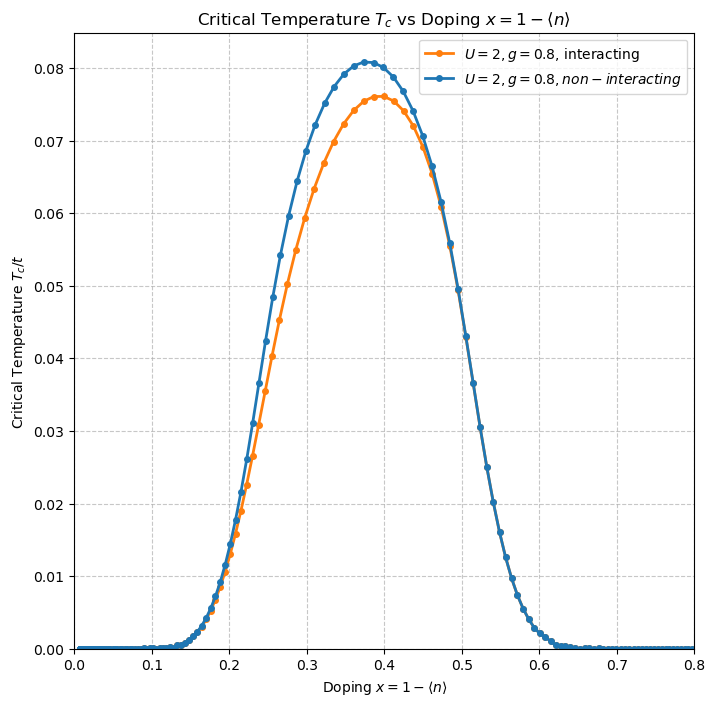

In [ ]:
#Fermi arc model Tc vs doping
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve
from scipy.optimize import brentq
import time

kB = 1.0
t = 1.0

t1 = -0.2
t2 = 0.1
#t1 = 0
#t2 = 0

d = 2.0    #spatial dimension
W = 4*d*t  #band width
#g = 0.1*W  #pair coupling
g = 0.8

Q = [np.pi, np.pi]
#Q = [0, 0]

#U = 0.1*W
U = 2

Nk = 256
kx_list = np.linspace(0, np.pi, Nk, endpoint=False)
ky_list = np.linspace(0, np.pi, Nk, endpoint=False)
KX, KY = np.meshgrid(kx_list, ky_list)
N = Nk * Nk

def band(kx, ky):
    return -2.0*t*(np.cos(kx) + np.cos(ky)) - 4.0*t1*np.cos(kx)*np.cos(ky) - 2*t2*(np.cos(2*kx) + np.cos(2*ky))

def band_Q(kx, ky):
    return -2.0*t*(np.cos(kx+Q[0]) + np.cos(ky+Q[1])) - 4.0*t1*np.cos(kx+Q[0])*np.cos(ky+Q[1]) - 2*t2*(np.cos(2*(kx+Q[0])) + np.cos(2*(ky+Q[1])))

def occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T):
    epsilon_minus_mu = epsilon - mu
    epsilon_Q_minus_mu = epsilon_Q - mu
    if T < 1e-8:
        T = 1e-8
    beta = 1.0/T
    E_1 = -beta*epsilon_Q_minus_mu
    E_2 = -beta*(epsilon_minus_mu + epsilon_Q_minus_mu + U)
    E_3 = -beta*epsilon_minus_mu
    E_0 = np.full_like(E_1, 0)
    E_max = np.maximum.reduce([E_0, E_1, E_2, E_3])
    numerator = np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    denominator = np.exp(E_0 - E_max) + np.exp(E_3 - E_max) + np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    return numerator/denominator

def chi0_hk(T, mu, U):
    if T < 1e-8:
        T = 1e-8
    beta = 1.0/T
    epsilon = band(KX, KY)
    epsilon_Q = band_Q(KX, KY)
    n_k = occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T)
    epsilon_minus_mu = epsilon - mu
    epsilon_Q_minus_mu = epsilon_Q - mu
    gamma = np.cos(KX) - np.cos(KY)
    #gamma = 1
    
    term_1_denominator = 2.0*epsilon_minus_mu
    term_1_numerator = gamma*gamma*(1.0 - n_k)*np.tanh(beta*epsilon_minus_mu/2.0)
    term_1 = np.where(np.abs(epsilon_minus_mu) < 1e-6, 
                      (1.0 - n_k)*beta/4.0,
                     term_1_numerator/term_1_denominator)
    
    epsilon_plus_U = epsilon_minus_mu + U
    term_2_denominator = 2.0*epsilon_plus_U
    term_2_numerator = gamma*gamma*n_k*np.tanh(beta*epsilon_plus_U/2.0)
    term_2 = np.where(np.abs(epsilon_plus_U) < 1e-6, 
                      n_k*beta/4.0,
                     term_2_numerator/term_2_denominator)

    term_3_denominator = 2.0*epsilon_minus_mu + U
    term_3_numerator = gamma*gamma*n_k*(1-n_k)*U*(np.tanh(beta*epsilon_plus_U/2.0)/2/epsilon_plus_U - np.tanh(beta*epsilon_minus_mu/2.0)/2/epsilon_minus_mu)
    term_3 = term_3_numerator/term_3_denominator
    #term_3 = 0
    
    chi0 = np.sum(term_1 + term_2 + term_3)/N
    return chi0

def tc_equation(T, mu, U, g):
    return g*chi0_hk(T, mu, U) - 1.0

def find_Tc(mu, U, g):
    T_max = 1.0
    T_min = 1e-7
    if tc_equation(T_max, mu, U, g) > 0:
        T_high = T_max
        while tc_equation(T_high, mu, U, g) > 0 and T_high < 10.0:
            T_high *= 2
        T_max = T_high
        print('T_high=', T_max)
    if tc_equation(T_min, mu, U, g) < 0:
        print('mu =', mu, 'low Tc')
        return 0.0
    try:
        Tc = brentq(tc_equation, T_min, T_max, args=(mu, U, g))
        return Tc
    except ValueError:
        return 0.0
    return Tc

def average_occupation(mu, T, U, KX, KY, N):
    epsilon = band(KX, KY)
    epsilon_Q = band_Q(KX, KY)
    n_k = occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T)
    return 2.0*np.sum(n_k) / N

mu_list = np.linspace(0.70, -2.55, 150)  #U=2.0
#mu_list = np.linspace(0.5, -2.75, 150)  #U=1.7
#mu_list = np.linspace(0.1, -3.15, 150)  #U=1.4
#mu_list = np.linspace(-0.15, -3.4, 150)  #U=1.1

Tc_results = []
Doping_x_results = []

start_time = time.time()
for mu in mu_list:
    Tc = find_Tc(mu, U, g)
    T_threshold = 1e-6
    if Tc > T_threshold:
        avg_n = average_occupation(mu, Tc, U, KX, KY, N)
        doping_x = 1.0 - avg_n
    else:
        avg_n = average_occupation(mu, T_threshold, U, KX, KY, N)
        doping_x = 1.0 - avg_n
    print('mu =', mu, 'dopping_x =', doping_x, 'Tc =', Tc)
    Tc_results.append(Tc)
    Doping_x_results.append(doping_x)

x_plot = np.array(Doping_x_results)
Tc_plot = np.array(Tc_results)

mask_lower = x_plot >= -0
mask_upper = x_plot < 0.8
mask_combined = mask_lower & mask_upper

Tc_final = Tc_plot[mask_combined]
x_final = x_plot[mask_combined]

sort_indices = np.argsort(x_final)
x_final = x_final[sort_indices]
Tc_final = Tc_final[sort_indices]

end_time = time.time()
print(end_time-start_time)


def chi0_hk(T, mu, U):
    if T < 1e-8:
        T = 1e-8
    beta = 1.0/T
    epsilon = band(KX, KY)
    epsilon_Q = band_Q(KX, KY)
    n_k = occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T)
    epsilon_minus_mu = epsilon - mu
    epsilon_Q_minus_mu = epsilon_Q - mu
    gamma = np.cos(KX) - np.cos(KY)
    #gamma = 1
    
    term_1_denominator = 2.0*epsilon_minus_mu
    term_1_numerator = gamma*gamma*(1.0 - n_k)*np.tanh(beta*epsilon_minus_mu/2.0)
    term_1 = np.where(np.abs(epsilon_minus_mu) < 1e-6, 
                      (1.0 - n_k)*beta/4.0,
                     term_1_numerator/term_1_denominator)
    
    epsilon_plus_U = epsilon_minus_mu + U
    term_2_denominator = 2.0*epsilon_plus_U
    term_2_numerator = gamma*gamma*n_k*np.tanh(beta*epsilon_plus_U/2.0)
    term_2 = np.where(np.abs(epsilon_plus_U) < 1e-6, 
                      n_k*beta/4.0,
                     term_2_numerator/term_2_denominator)

    term_3_denominator = 2.0*epsilon_minus_mu + U
    term_3_numerator = gamma*gamma*n_k*(1-n_k)*U*(np.tanh(beta*epsilon_plus_U/2.0)/2/epsilon_plus_U - np.tanh(beta*epsilon_minus_mu/2.0)/2/epsilon_minus_mu)
    term_3 = term_3_numerator/term_3_denominator
    term_3 = 0
    
    chi0 = np.sum(term_1 + term_2 + term_3)/N
    return chi0

def tc_equation(T, mu, U, g):
    return g*chi0_hk(T, mu, U) - 1.0

def find_Tc(mu, U, g):
    T_max = 1.0
    T_min = 1e-7
    if tc_equation(T_max, mu, U, g) > 0:
        T_high = T_max
        while tc_equation(T_high, mu, U, g) > 0 and T_high < 10.0:
            T_high *= 2
        T_max = T_high
        print('T_high=', T_max)
    if tc_equation(T_min, mu, U, g) < 0:
        print('mu =', mu, 'low Tc')
        return 0.0
    try:
        Tc = brentq(tc_equation, T_min, T_max, args=(mu, U, g))
        return Tc
    except ValueError:
        return 0.0
    return Tc

def average_occupation(mu, T, U, KX, KY, N):
    epsilon = band(KX, KY)
    epsilon_Q = band_Q(KX, KY)
    n_k = occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T)
    return 2.0*np.sum(n_k) / N

Tc_results_0 = []
Doping_x_results_0 = []

start_time = time.time()
for mu in mu_list:
    Tc = find_Tc(mu, U, g)
    T_threshold = 1e-6
    if Tc > T_threshold:
        avg_n = average_occupation(mu, Tc, U, KX, KY, N)
        doping_x = 1.0 - avg_n
    else:
        avg_n = average_occupation(mu, T_threshold, U, KX, KY, N)
        doping_x = 1.0 - avg_n
    #print('dopping_x =', doping_x, 'Tc =', Tc)
    Tc_results_0.append(Tc)
    Doping_x_results_0.append(doping_x)

x_plot_0 = np.array(Doping_x_results_0)
Tc_plot_0 = np.array(Tc_results_0)

mask_lower = x_plot_0 >= 0.0
mask_upper = x_plot_0 < 0.8
mask_combined = mask_lower & mask_upper

Tc_final_0 = Tc_plot_0[mask_combined]
x_final_0 = x_plot_0[mask_combined]

sort_indices = np.argsort(x_final_0)
x_final_0 = x_final_0[sort_indices]
Tc_final_0 = Tc_final_0[sort_indices]

end_time = time.time()
print(end_time-start_time)

plt.figure(figsize=(8, 8))
#plt.plot(x_final, Tc_final, 'ro-', linewidth=2, markersize=4, label=f'$U={U}, g={g}$, interacting')
#plt.plot(x_final_0, Tc_final_0, 'co-', linewidth=2, markersize=4, label=f'$U={U}, g={g}, non-interacting$')
plt.plot(x_final, Tc_final, 'o-', color='tab:orange', linewidth=2, markersize=4, label=f'$U={U}, g={g}$, interacting')
plt.plot(x_final_0, Tc_final_0, 'o-', color='tab:blue', linewidth=2, markersize=4, label=f'$U={U}, g={g}, non-interacting$')
plt.title(f'Critical Temperature $T_c$ vs Doping $x = 1 - \\langle n \\rangle$')
plt.xlabel('Doping $x = 1 - \\langle n \\rangle$')
plt.ylabel('Critical Temperature $T_c / t$')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 0.8)
plt.ylim(bottom=0)
plt.legend()
#plt.savefig(f'U={U}_g={g}.png')
plt.show() 
#np.save(f'Tc_U={U}_g={g}', Tc_final)
#np.save(f'x_U={U}_g={g}', x_final)
#np.save(f'Tc0_U={U}_g={g}', Tc_final_0)
#np.save(f'x0_U={U}_g={g}', x_final_0)

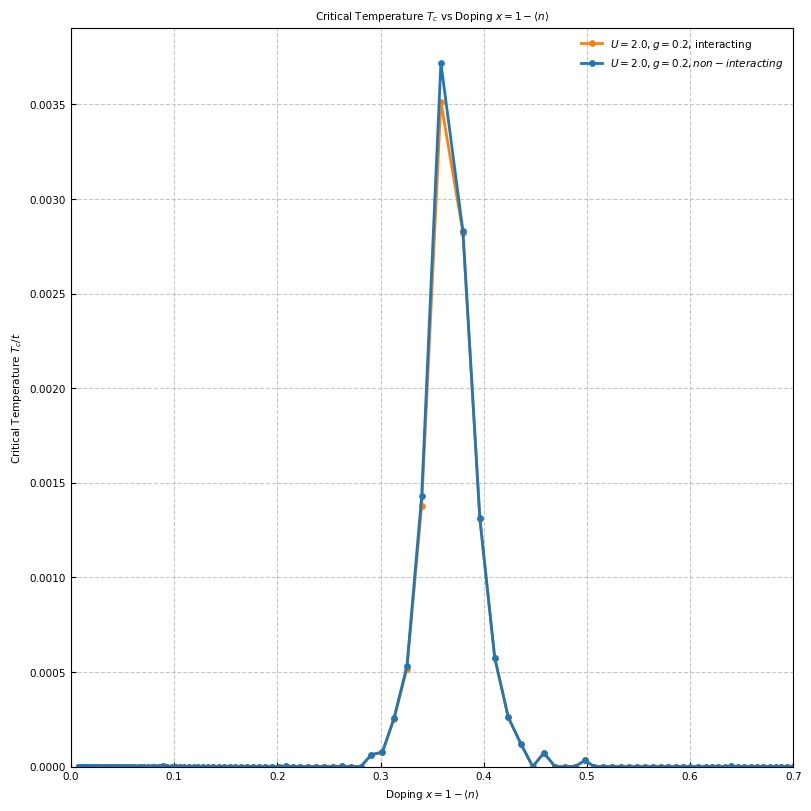

In [20]:
#Fermi arc model Tc equation 25 (non-interacting interacting splited)
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve
from scipy.optimize import brentq
import time

U = 2.0
g = 0.2

x_final = np.load(f'x_U={U}_g={g}.npy')
x_final_0 = np.load(f'x0_U={U}_g={g}.npy')
Tc_final = np.load(f'Tc_U={U}_g={g}.npy')
Tc_final_0 = np.load(f'Tc0_U={U}_g={g}.npy')

plt.figure(figsize=(8, 8))
#plt.plot(x_final, Tc_final, 'ro-', linewidth=2, markersize=4, label=f'$U={U}, g={g}$, interacting')
#plt.plot(x_final_0, Tc_final_0, 'co-', linewidth=2, markersize=4, label=f'$U={U}, g={g}$, interacting')
plt.plot(x_final, Tc_final, 'o-', color='tab:orange', linewidth=2, markersize=4, label=f'$U={U}, g={g}$, interacting')
plt.plot(x_final_0, Tc_final_0, 'o-', color='tab:blue', linewidth=2, markersize=4, label=f'$U={U}, g={g}, non-interacting$')
plt.title(f'Critical Temperature $T_c$ vs Doping $x = 1 - \\langle n \\rangle$')
plt.xlabel('Doping $x = 1 - \\langle n \\rangle$')
plt.ylabel('Critical Temperature $T_c / t$')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 0.7)
plt.ylim(bottom=0)
plt.legend()
plt.savefig(f'U={U}_g={g}.png')
plt.show() 